In [1]:
import numpy as np
import torch as torch
import os
import copy
import random
from scipy.optimize import nnls,curve_fit,leastsq
import time

In [2]:
diffusion_model='ivim'

In [3]:
b_list=np.array([30,50,100,150,300,400,500])/1000
out_num=4
phase='train'

In [4]:
data_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\data_dict.pth")
val_signals,val_parameters=data_dict[phase]['Multi']

val_signals=val_signals[:,1:]/val_signals[:,0].reshape(-1,1)

In [5]:
parameters0=[[0.75,100.,0.80]]

In [6]:
def translation(code):
    d0=code[:,0].reshape(-1,1)
    d1=code[:,1].reshape(-1,1)   
    f0=code[:,2].reshape(-1,1) 
    f1=1-f0
    signals=f0*np.exp(-b_list*d0)+f1*np.exp(-b_list*d1)
    parameters=np.concatenate((d0,d1,f0,f1), axis=1)
    return signals,parameters

def equation(b, dslow,dfast,fslow):
    return fslow*np.exp(-b*dslow) + (1-fslow)*np.exp(-b*dfast)

def order(dslow,dfast,fslow):
    if dfast < dslow:
        dfast, dslow = dslow, dfast
        fslow = 1-fslow   
    return np.array([dslow,dfast,fslow,1-fslow])

def fit_least_squares(X,Y,p0):
    try:
        bounds = ([0., 0, 0.], [1, 200., 1.])
        params, _ = curve_fit(equation, X, Y, p0=p0, bounds=bounds)
        dslow,dfast,fslow = params[0], params[1], params[2]
        return order(dslow,dfast,fslow)
    except:
        return np.array([0,0,0,0])
    
        
def FIT(signals):
    x,y=signals.shape
    lsq_parameters=np.zeros((x, out_num)) 
    for i in range(x):
        if (i+1)%200==0:
            print(i)
        Y=signals[i,:]
        Yt=Y.reshape(1,-1)
        loss_min=1000
        for j in range(len(parameters0)): 
            p=parameters0[j]
            temp_parameters=fit_least_squares(b_list,Y,p)
            temp_parameters=np.array(temp_parameters).reshape(1,-1)
            temp_signals,_=translation(temp_parameters)
            loss=np.mean((Yt-temp_signals)**2)
            if loss<loss_min:
                    loss_min=loss
                    parameters=temp_parameters 
        lsq_parameters[i,:]=parameters
    return lsq_parameters

In [7]:
since = time.time()
generate_parameters=FIT(val_signals.numpy())

time_elapsed = time.time() - since

199
399
599
799
999
1199
1399
1599
1799
1999
2199
2399
2599
2799
2999
3199
3399
3599
3799
3999
4199
4399
4599
4799
4999
5199
5399
5599
5799
5999
6199
6399
6599
6799
6999
7199
7399
7599
7799
7999
8199
8399
8599
8799
8999
9199
9399
9599
9799
9999


In [8]:
time_elapsed/val_parameters.shape[0]

0.0013122794151306152

In [9]:
if diffusion_model=='ivim':
    generate_parameters[:,:2]=generate_parameters[:,:2]/1000
else:
    generate_parameters[:,:1]=generate_parameters[:,:1]/1000

In [11]:
diff_parameters=torch.tensor(generate_parameters)-torch.tensor(val_parameters)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_7952\438319740.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  diff_parameters=torch.tensor(generate_parameters)-torch.tensor(val_parameters)


In [12]:
parameter_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")
parameter_dict['lsq'+phase]=generate_parameters
torch.save(parameter_dict,r"G:\zhouxinxiang\MRL_HN\simulation\parameter_dict.pth")

In [13]:
error_dict=torch.load(r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")
error_dict['lsq'+phase]=diff_parameters
torch.save(error_dict,r"G:\zhouxinxiang\MRL_HN\simulation\error_dict.pth")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


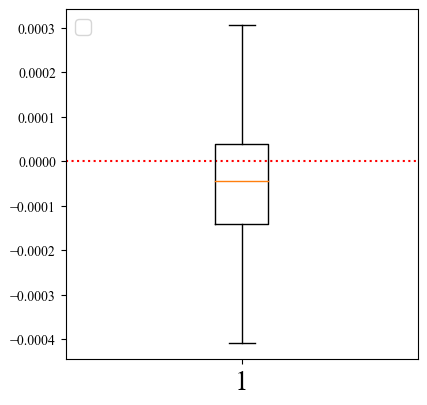

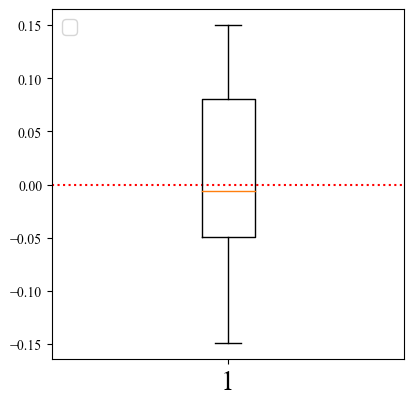

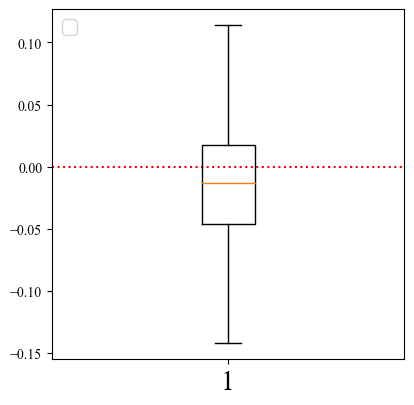

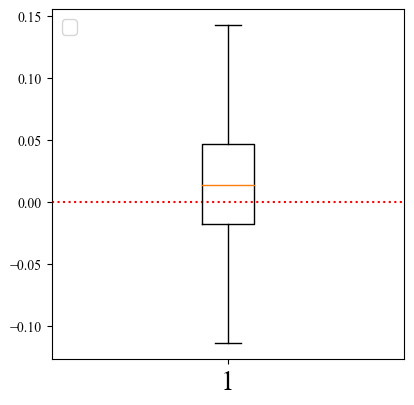

In [17]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,0].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,2)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,1].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,3)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,2].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

plt.rc('font',family='Times New Roman')
plt.figure(figsize=(10,10))
plt.subplot(2,2,4)
plt.xticks(fontsize=20)
#plt.yticks(np.arange(-10, 10, 5)/10000,fontsize=20)
plt.axhline(y=0., color='r', linestyle=':')
plt.boxplot(diff_parameters.cpu()[:,3].detach().numpy(),showfliers=False)
plt.xlabel("")
plt.ylabel("")
plt.legend(loc = 'upper left',fontsize=14)

